# Usage Example of Pyspectrum
pyspectrum is a package that helps with handeling spectra.\
The package includes spectrum realization via xarray and other standard python tools.\
In here, the basic use of PySpectrum is presented.\
We'll load a spectrum and calibrate it and normlized it.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create calibrated Spectrum 
from pyspectrum.core import Spectrum, Domain
from pyspectrum.io import TimeChannelParser
from pyspectrum.calibration.models.hpge_fwhm_model import StandardHPGeFWHMModel
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration
from pyspectrum.calibration.detector_calibration import DetectorCalibration, StandardHPGeFWHMModel, PolynomialEnergyModel
from pyspectrum.background.snip import SNIPBackground
from pyspectrum.domain_characterization.background import domain_erf_background
from pyspectrum.domain_characterization.background import domain_linear_background

from pyspectrum.domain_characterization.morphology import peak_positions, find_domain_peaks

# Loading a new spectrum
The spectrum is of Eu152, and there was not calibration yet.

In [2]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'
spectrum = pd.read_csv(path, names=['counts'])
first_non_zero = np.where(spectrum["counts"]>0)[0][0]
#first_non_zero = 0
spectrum = spectrum[first_non_zero:].reset_index(drop=True)
spectrum['channel'] = spectrum.index

spectrum = Spectrum.from_dataframe(df=spectrum, channel_col="channel", counts_col="counts")

In [3]:
spectrum

<xarray.DataArray (channel: 8109)>
array([19919, 25115, 26717, ...,     3,     4,     3], dtype=int64)
Coordinates:
  * channel  (channel) int64 0 1 2 3 4 5 6 ... 8103 8104 8105 8106 8107 8108

Text(0, 0.5, 'Counts')

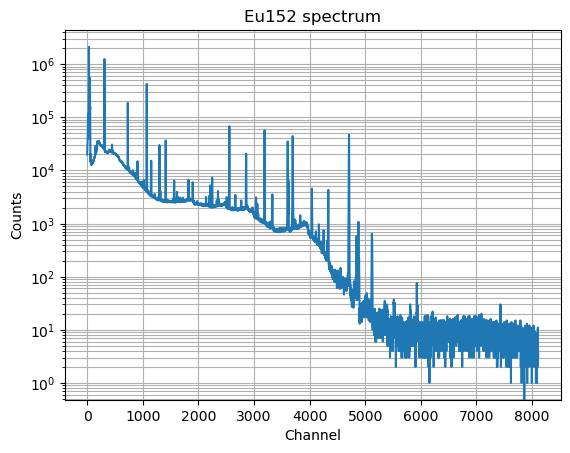

In [4]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Channel')
plt.ylabel('Counts')

## calibration generator

choose the obvious photobpeaks in the spectrum

uncomment here if you wat to see the what are the dominenent peaks in the spectrum

In [5]:
#import curie
#Eu152 =  curie.Isotope('EU-152')
#gamma_df = Eu152.gammas()
#gamma_df[gamma_df['intensity']>5]
#
#gamma_df = Eu152.gammas()
#gamma_df[gamma_df['intensity']>5]

In [6]:
#domains = [(383, 403), (1140,1165), (2627, 2650), (3260,3285), (3680, 3695), (3770,3790), (4770, 4810)]
# the domain after adding the first_non_zero
domains = [(300,320),(1057,1082),(2544,2567),(3177,3202),(3597,3612),(3687,3707),(4687,4727)]
energies = [121.78, 344.28, 778.9, 964.08, 1085.8370, 1112.0760, 1408]
detector_calibration = DetectorCalibration(spectrum,
                                           known_axis_values=energies, peak_domains=domains,
                                          energy_model=PolynomialEnergyModel(2), fwhm_model=StandardHPGeFWHMModel())

In [7]:
energy_calib, fwhm_calib = detector_calibration.generate(energy_p0=(0,1,0), fwhm_p0=(0,1,0))

In [8]:
spectrum.set_axis_calibration(energy_calib)
spectrum.set_resolution_calibration(fwhm_calib)

Text(0, 0.5, 'Counts')

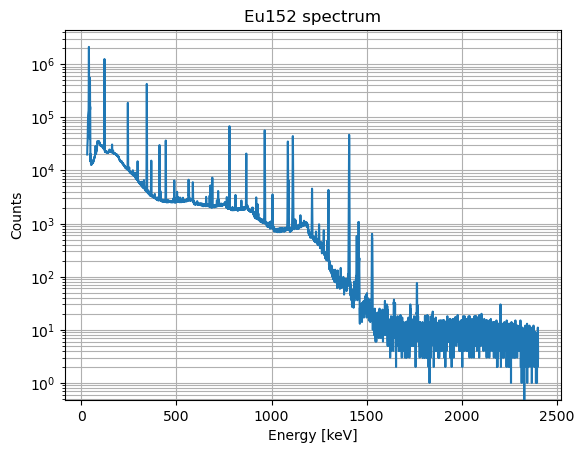

In [9]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')

find the calibration

In [10]:
detector_calibration = DetectorCalibration(spectrum,
                                           known_axis_values=energies, peak_domains=domains,
                                          energy_model=PolynomialEnergyModel(2), fwhm_model=StandardHPGeFWHMModel())
peaks_center_ch, fwhm_val = detector_calibration.estimate_peaks()

In [11]:
fwhm_energy_val = [spectrum.axis[int(ch_center+fwhm_val[i])]-spectrum.axis[int(ch_center)] for i, ch_center in enumerate(np.round(peaks_center_ch))]

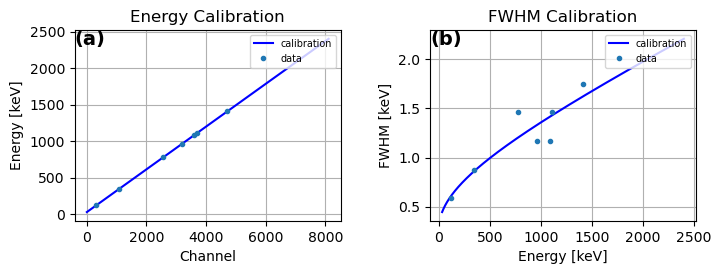

In [12]:
# === Create Side-by-Side Figure ===
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(7.1, 2.625), constrained_layout=True, gridspec_kw={'wspace': 0.1} )

# === Left plot: Energy Calibration ===
ax1.plot(spectrum.channels, spectrum.axis_calib.apply(spectrum.channels), 'b-', label='calibration')
ax1.plot(peaks_center_ch, spectrum.axis_calib.apply(peaks_center_ch), marker='.', ls='', label='data')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Energy [keV]')
ax1.set_title('Energy Calibration')
ax1.grid(which='both')
ax1.legend(fontsize='x-small', loc='upper right', frameon=True)
ax1.text(0, 1, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')

# === Right plot: FWHM  ===
ax2.plot(spectrum.axis_calib.apply(spectrum.channels), spectrum.resolution_calib.apply(spectrum.axis_calib.apply(spectrum.channels)), 'b-', label='calibration')
ax2.plot(energies, fwhm_energy_val, marker='.', ls='', label='data')
ax2.set_xlabel('Energy [keV]')
ax2.set_ylabel('FWHM [keV]')
ax2.set_title('FWHM Calibration')
ax2.grid(which='both')
ax2.legend(fontsize='x-small', loc='upper right', frameon=True)
ax2.text(0, 1.0, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')

# === Show ===
plt.show()


# Operations

Note that the spectrum object can be treated as an xarray (mostly)\
This means it can be normlized and operated easly

Text(0, 0.5, 'Counts rate [cps]')

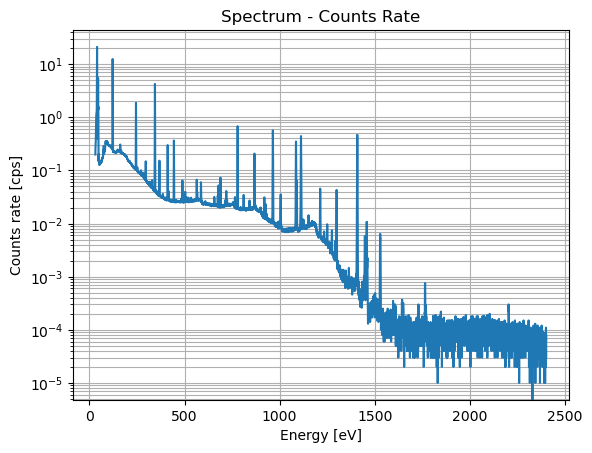

In [13]:
measurement_time = 1e5
(spectrum/measurement_time).plot(yscale='log')
plt.grid(True, which='both')
plt.title('Spectrum - Counts Rate')
plt.xlabel('Energy [eV]')
plt.ylabel('Counts rate [cps]')

## findPeaks
An example how to find domains in which the counts are above snr

In [14]:
# identification of peaks
from pyspectrum.identification import Convolution
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.kernels.mexican_hat import gaussian_2_dev

In [15]:
conv = Convolution(resolution=spectrum.resolution_calib.apply, kernel=gaussian_2_dev, window_fwhm=4)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=5, n_sigma_bg_threshold=2.5, persistence_factor=1)
domains = finder.find(spectrum)

(1000.0, 2000000.0)

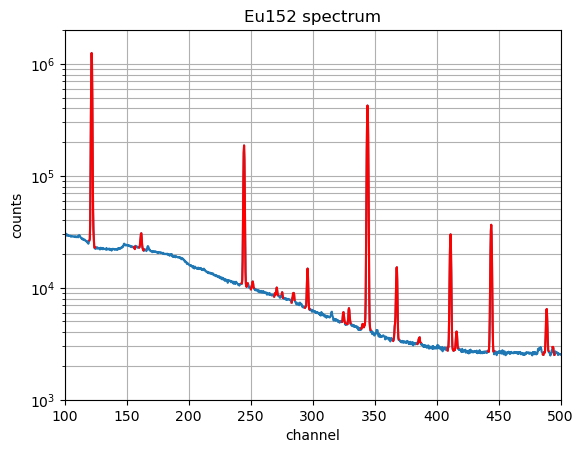

In [16]:
# note that using plot_all_peaks shows all the peaks in
plt.axes(yscale='log')
spectrum.plot()
for domain in domains:
    domain.plot(color='red')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('channel')
plt.ylabel('counts')
plt.xlim([100, 500])
plt.ylim([1e3, 2e6])

# bg

In [17]:
# global bg

In [18]:
snip_bg = SNIPBackground(15)
bg_estimation = snip_bg.estimate(axis=spectrum.axis, counts=spectrum.counts, resolution=spectrum.resolution_calib.apply, smoothing=True)
subtracted_spectrum = spectrum-bg_estimation

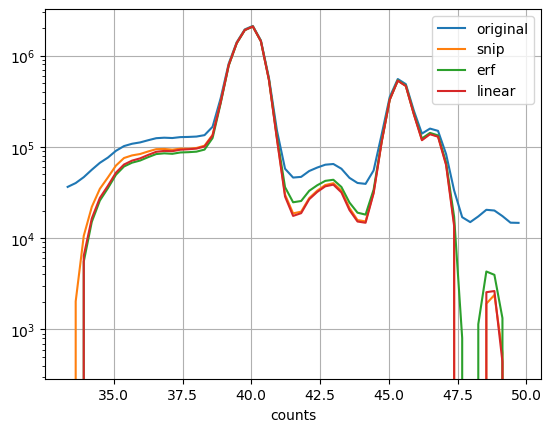

In [19]:
complex_domain = Domain(spectrum, start=8, stop=65)
complex_domain_subtracted = Domain(subtracted_spectrum, start=8, stop=65)

complex_domain.plot(yscale='log', label='original')
complex_domain_subtracted.plot(yscale='log', label='snip')

erf_bg = domain_erf_background(complex_domain)
lin_bg = domain_linear_background(complex_domain)

complex_domain.set_background(erf_bg)
complex_domain.plot(yscale='log', label='erf')

complex_domain.set_background(lin_bg)
complex_domain.plot(yscale='log', label='linear')

plt.xlabel("energy [keV]")
plt.xlabel("counts")
plt.legend()
plt.grid()

The peaks center can be found using the Mariscotti method

(33.32291415847578, 50.01184936724644)

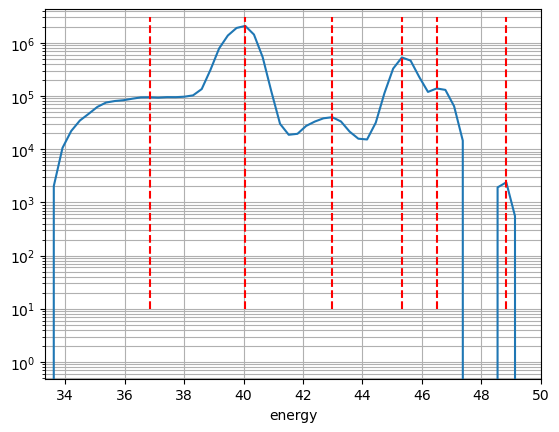

In [27]:
minimal_statistical_accuracy = 0.05
resolution = spectrum.resolution_calib.apply(25) / (2 * np.sqrt(2 * np.log(2)))
minimal_counts_in_peak = 1 / minimal_statistical_accuracy ** 2
minimal_prominence = minimal_counts_in_peak / (0.761438079 * np.sqrt(2 * np.pi) * resolution)

complex_domain.set_background(erf_bg)

complex_domain_subtracted.plot(yscale='log')

for c in peak_positions(complex_domain_subtracted, smooth=True, prominence=minimal_prominence):
    plt.vlines(ymax=3e6, ymin=10, x=c, color='red', ls='--')
plt.grid(True, which='both')
plt.xlim([spectrum.axis[complex_domain.start], spectrum.axis[complex_domain.stop]])

In [28]:
domain_peak_positions, domain_peak_propeties = find_domain_peaks(complex_domain, smooth=True, prominence=minimal_prominence)
domain_peak_positions

array([40.057087  , 42.98497089, 45.32727044, 46.4984177 , 48.54792134])

In [30]:
from pyspectrum.fitting.gauss import GaussianFitting

In [34]:
fitting_evaluation_axis = np.linspace(complex_domain.energy.values[0], complex_domain.energy.values[-1], num=int(1e5))
parms = GaussianFitting.fit(complex_domain, prominence=minimal_prominence)
val = GaussianFitting.evaluate(fitting_evaluation_axis, parms)

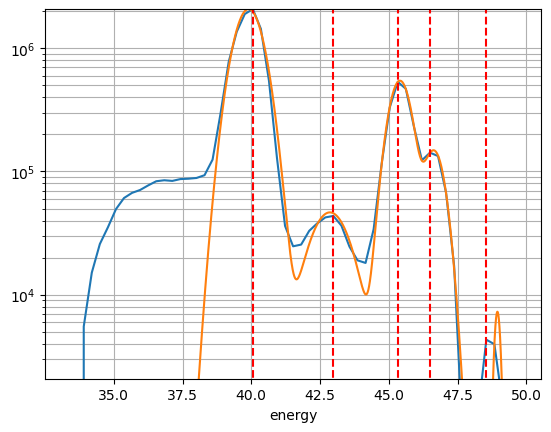

In [35]:
complex_domain.plot(yscale='log')
plt.plot(fitting_evaluation_axis, val)

for c in peak_positions(complex_domain, smooth=True, prominence=minimal_prominence):
    plt.vlines(ymax=3e6, ymin=10, x=c, color='red', ls='--')
plt.grid(True, which='both')

val = GaussianFitting.evaluate(np.linspace(complex_domain.energy.values[0], complex_domain.energy.values[-1], num=int(1e5)), parms)
plt.ylim([complex_domain.max()*1e-3, complex_domain.max()])
plt.yscale('log')